# Assignment 1 — Data and Probability Foundations

**Course:** Statistics and Data Analysis for Engineers (STA1)

**Group members:** _(add names here)_

## Table of contents

1. [Part 1 — Digital services](#part1)
2. [Part 2 — Smart-building measurements](#part2)
3. [Part 3 — Cybersecurity alert system](#part3)
4. [Part 4 — AI-use and conclusion](#part4)

Only methods from Sessions 1–2 are used: descriptive statistics (centre, spread, shape,
potential outliers) in Parts 1–2, and basic probability rules in Part 3.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "data/"

services = pd.read_csv(DATA + "assignment01_digital_services.csv")   # Part 1
building = pd.read_csv(DATA + "assignment01_smart_building.csv")     # Part 2

print(f"services: {services.shape[0]} rows x {services.shape[1]} columns")
print(f"building: {building.shape[0]} rows x {building.shape[1]} columns")

services: 144 rows x 4 columns
building: 96 rows x 6 columns


<a id="part1"></a>
# Part 1 — Digital services

> The file `assignment01_digital_services.csv` contains latency measurements and
> security-alert categories for three digital services.

## a)

> Identify the observational unit, the relevant population, and each variable as categorical or
> quantitative. Create a frequency table for `alert_type` containing counts and percentages.

In [2]:
services.info()
services.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   observation_id  144 non-null    int64  
 1   service         144 non-null    object 
 2   latency_ms      144 non-null    float64
 3   alert_type      144 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 4.6+ KB


,observation_id,service,latency_ms,alert_type
0,1,orders,112.70,none
1,2,orders,109.83,none
2,3,telemetry,99.02,none
3,4,telemetry,94.44,none
4,5,telemetry,97.09,none


**Observational unit.** One row is **one request handled by one of the three services**,
identified by `observation_id`. Every value in that row describes that single request.

**Population.** All requests these three services handle during normal operation.
The 144 rows in the file are a **sample** from that stream, so everything computed below is a
**statistic** (a summary of the sample), not a **parameter** (a summary of the population).

**Variables.**

| variable | type | notes |
|---|---|---|
| `observation_id` | identifier / index | row label only — not a measurement, so we never average it |
| `service` | **categorical** (nominal) | 3 labels: `orders`, `identity`, `telemetry` |
| `latency_ms` | **quantitative, continuous** | response time in milliseconds |
| `alert_type` | **categorical** (nominal) | 4 labels; `none` means no alert was raised |

### Frequency table for `alert_type`

In [3]:
counts = services["alert_type"].value_counts()

freq = pd.DataFrame({"count": counts})
freq["percent"] = (freq["count"] / len(services) * 100).round(1)
freq.loc["total"] = freq.sum()
freq["count"] = freq["count"].astype(int)
freq.index.name = "alert_type"

freq

,count,percent
alert_type,,
none,104,72.2
authentication,25,17.4
rate_limit,9,6.2
injection_signature,6,4.2
total,144,100.0


**Interpretation.** Almost three quarters of the requests (104 of 144, 72.2 %) raise **no alert**.
Of the alerts that do occur, `authentication` is by far the most common (25 requests, 17.4 %),
while `rate_limit` (9) and `injection_signature` (6) are rare. The last two categories rest on
very few observations, so any statement about them individually is weakly supported by this sample.

## b)

> For `latency_ms`, report the sample size, mean, median, sample standard deviation, minimum,
> $Q_1$, $Q_3$, maximum, and IQR:
> - for all observations combined; and
> - separately for each service.

The same helper is applied to the whole sample and to each service, so the rows are directly
comparable. `describe()` already returns n, mean, sample standard deviation (divisor **n − 1**),
min, Q1, median and Q3 — we only add the IQR and rename the labels to the ones used in the course.

In [4]:
def summary(x):
    """n, mean, median, sample sd (n-1), min, Q1, Q3, max and IQR for one numeric column."""
    s = x.describe()                 # count, mean, std (ddof=1), min, 25%, 50%, 75%, max
    s["IQR"] = s["75%"] - s["25%"]
    return s.rename({"count": "n", "std": "sd", "25%": "Q1", "50%": "median", "75%": "Q3"})


ORDER = ["n", "mean", "median", "sd", "min", "Q1", "Q3", "max", "IQR"]

overall = summary(services["latency_ms"]).rename("all services").to_frame().T
by_service = services.groupby("service")["latency_ms"].apply(summary).unstack()

latency_summary = pd.concat([overall, by_service])[ORDER].round(2)
latency_summary

,n,mean,median,sd,min,Q1,Q3,max,IQR
all services,144.0,110.11,106.93,23.10,75.21,95.84,116.88,223.80,21.04
identity,49.0,96.07,93.72,16.12,75.21,85.39,105.10,154.27,19.71
orders,50.0,122.20,114.52,24.81,98.53,109.84,124.15,223.80,14.31
telemetry,45.0,111.97,106.92,19.38,86.78,97.95,116.83,177.87,18.88


**Interpretation.**

- **Typical latency.** `identity` is the fastest service (median 93.72 ms), `telemetry` is in the
  middle (106.92 ms) and `orders` is the slowest (114.52 ms).
- **Spread.** `orders` has the **largest standard deviation** (24.81 ms) but the **smallest IQR**
  (14.31 ms). These two disagree because they measure different things: the IQR describes only the
  middle 50 % of requests, which for `orders` are tightly packed, while the standard deviation uses
  *every* value and is therefore pulled up by a few very slow requests (max 223.80 ms).
- **Mean vs median.** In all four rows the mean is **above** the median
  (e.g. `orders`: 122.20 vs 114.52). That gap is the signature of a **right-skewed** distribution —
  a minority of slow requests drags the mean up, while the median stays with the bulk of the data.
- **Check.** 49 + 50 + 45 = 144, so every row belongs to exactly one service.

## c)

> Create a histogram of all latency measurements and side-by-side boxplots for the three services.
> Explain the histogram's axes, bins, and displayed shape and the boxplot's median, box, whiskers,
> and plotted potential outliers.

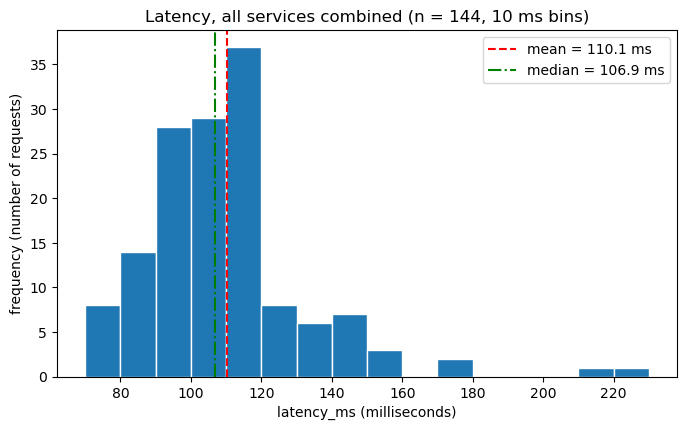

In [5]:
latency = services["latency_ms"]

# Fixed 10 ms bins from 70 to 230 ms: wide enough to show the shape,
# narrow enough not to hide the tail.
bins = np.arange(70, 231, 10)

plt.figure(figsize=(8, 4.5))
plt.hist(latency, bins=bins, edgecolor="white")
plt.axvline(latency.mean(), color="red", linestyle="--",
            label=f"mean = {latency.mean():.1f} ms")
plt.axvline(latency.median(), color="green", linestyle="-.",
            label=f"median = {latency.median():.1f} ms")
plt.xlabel("latency_ms (milliseconds)")
plt.ylabel("frequency (number of requests)")
plt.title(f"Latency, all services combined (n = {len(latency)}, 10 ms bins)")
plt.legend()
plt.show()

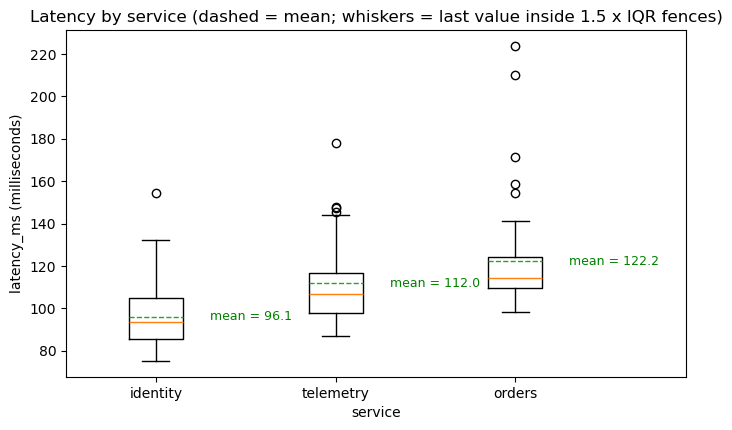

In [6]:
# Services ordered by median latency: fastest on the left.
order = ["identity", "telemetry", "orders"]
groups = [services.loc[services["service"] == s, "latency_ms"] for s in order]

plt.figure(figsize=(8, 4.5))
# showmeans + meanline draws the mean as a dashed line across each box.
plt.boxplot(groups, labels=order, showmeans=True, meanline=True)

# Print each mean beside its mean line so the value can be read off the plot.
# One decimal here; the exact values are in the summary table in (b).
for i, g in enumerate(groups, start=1):
    plt.text(i + 0.30, g.mean(), f"mean = {g.mean():.1f}",
             va="center", fontsize=9, color="green")

plt.xlim(0.5, 3.95)   # room on the right for the third label

plt.xlabel("service")
plt.ylabel("latency_ms (milliseconds)")
plt.title("Latency by service (dashed = mean; whiskers = last value inside 1.5 x IQR fences)")
plt.show()

**Reading the histogram.**

- The **horizontal axis** is `latency_ms`, split into equal intervals (**bins**) 10 ms wide,
  running from 70 ms to 230 ms.
- The **vertical axis** is the **frequency**: how many requests fall into each bin. The bar heights
  add up to n = 144.
- **Bin width matters.** Much wider bins would merge the tail into the main peak and hide it;
  much narrower bins would break 144 observations into near-empty bars that look like noise.
- **Shape.** One clear peak (**unimodal**) around 90–115 ms with a **long tail to the right**
  reaching past 200 ms. Because skewness is named after the tail, this is **right-skewed**.
  The red mean line sits to the right of the green median line, which is exactly what right skew does.

**Reading the boxplots.**

- The **box** runs from Q1 to Q3, so it covers the middle 50 % of that service's requests;
  its height is the **IQR**.
- The **solid line inside the box** is the **median** (Q2). It sits below the centre of the box
  for each service, another sign of right skew.
- The **dashed line** is the **mean**, with its value printed beside it (96.1, 112.0 and 122.2 ms —
  the exact figures are in the table in (b)). It lies **above** the median in all three services,
  so the boxplot shows the same right skew as the histogram: the few slow requests pull the mean up
  but leave the median where the bulk of the data is.
- The **whiskers** reach the lowest and highest values that are still **inside** the
  1.5 × IQR fences. They are not the overall min and max.
- The **individual points above the whiskers** are observations outside the fences —
  **potential outliers**, listed in (d). They are plotted, not deleted.
- Drawing the three boxes on one axis makes level (box position), spread (box height) and skew
  (median position, whisker lengths) comparable at a glance: `orders` sits highest but has the
  shortest box, and every extreme point lies on the high side.

## d)

> Apply the $1.5 \times \text{IQR}$ rule within each service. Report the IDs and values of potential
> outliers, retain them in the analysis, and explain why a plotted outlier is not automatically a
> data error.

Each service is judged against **its own** quartiles:

$$\text{lower fence} = Q_1 - 1.5 \times IQR \qquad
  \text{upper fence} = Q_3 + 1.5 \times IQR$$

In [7]:
fences = services.groupby("service")["latency_ms"].agg(
    Q1=lambda s: s.quantile(0.25),
    Q3=lambda s: s.quantile(0.75),
)
fences["IQR"] = fences["Q3"] - fences["Q1"]
fences["lower_fence"] = fences["Q1"] - 1.5 * fences["IQR"]
fences["upper_fence"] = fences["Q3"] + 1.5 * fences["IQR"]

fences.round(2)

,Q1,Q3,IQR,lower_fence,upper_fence
service,,,,,
identity,85.39,105.10,19.71,55.83,134.66
orders,109.84,124.15,14.31,88.37,145.61
telemetry,97.95,116.83,18.88,69.63,145.15


In [8]:
# Attach each row's own service fences, then keep the rows that fall outside them.
checked = services.join(fences[["lower_fence", "upper_fence"]], on="service")

outliers = checked[
    (checked["latency_ms"] < checked["lower_fence"])
    | (checked["latency_ms"] > checked["upper_fence"])
].sort_values(["service", "latency_ms"])

print(f"{len(outliers)} potential outliers flagged.")
print(f"All {len(services)} rows are kept — nothing is removed from the analysis.")

outliers[["observation_id", "service", "latency_ms", "upper_fence"]].reset_index(drop=True)

10 potential outliers flagged.
All 144 rows are kept — nothing is removed from the analysis.


,observation_id,service,latency_ms,upper_fence
0,132,identity,154.27,134.6650
1,87,orders,154.32,145.6125
2,66,orders,158.59,145.6125
3,60,orders,171.59,145.6125
4,19,orders,210.10,145.6125
5,88,orders,223.80,145.6125
6,39,telemetry,145.52,145.1500
7,33,telemetry,147.26,145.1500
8,120,telemetry,147.79,145.1500
9,133,telemetry,177.87,145.1500


**Result.** 10 of 144 requests are flagged, **all above the upper fence** — no service has a
low-side outlier. They are split as `orders` 5 (IDs 87, 66, 60, 19, 88; up to 223.80 ms),
`telemetry` 4 (IDs 39, 33, 120, 133) and `identity` 1 (ID 132). All 144 rows stay in the dataset;
every table and plot above already includes them.

**Why a flagged point is not automatically a data error.** The 1.5 × IQR rule is a purely
**mechanical** screen — it measures distance from the quartiles and knows nothing about how the
data were produced. Two things follow:

1. **The values are physically plausible.** They are latencies of 145–224 ms: slow, but perfectly
   possible for a real request. Nothing here is impossible the way a negative time would be.
2. **Right-skewed data flag points by construction.** Latency has a natural floor and no ceiling,
   so occasional slow requests (a cache miss, a retry, a garbage-collection pause, a cold start)
   are normal behaviour, not measurement failures. A healthy system still produces them.

Deleting them would push the mean, standard deviation and maximum downward and hide exactly the
slow-request behaviour that matters most in operations. The rule from Session 1 is therefore
**flag → investigate → explain**, not *flag → delete*. A point should only be removed when there
is independent evidence that the measurement itself is invalid, for example a documented
sensor or logging fault.

## e)

> Write a short descriptive comparison of the services. Comment on typical latency, spread,
> skewness, the relationship between mean and median, and what cannot be generalised from these
> descriptive differences alone.

- **Typical latency.** `identity` is fastest (median 93.72 ms), `telemetry` sits in the middle
  (106.92 ms), and `orders` is slowest (114.52 ms). The ordering is the same whether the mean or
  the median is used, and it is visible as a vertical offset between the three boxes.

- **Spread.** The two spread measures tell different stories for `orders`, and both are correct.
  Its IQR is the **smallest** of the three (14.31 ms) — its ordinary requests are the most
  consistent — but its standard deviation is the **largest** (24.81 ms) and its maximum is
  223.80 ms. `orders` is therefore *predictable most of the time but has the worst bad cases*.
  `identity` is the most consistent overall (sd 16.12 ms), with `telemetry` between the two.

- **Skewness.** All three services are **right-skewed**: the histogram has a long right tail,
  each boxplot has a longer upper whisker with points above it, and all 10 flagged outliers are
  on the high side. There is no left tail anywhere.

- **Mean versus median.** Because of that skew the mean sits above the median everywhere
  (the gap is largest for `orders`: 122.20 vs 114.52). The **median is the better description of a
  typical request**, since it is resistant to the few slow ones; the **mean is more informative
  about total cost**, because it does absorb them. Reporting only one of the two would be misleading.

- **What cannot be generalised from this.** These are **descriptive** statements about
  **144 observed requests**. They do not show that `orders` is inherently slower — nothing here
  rules out the differences being an artefact of this particular sample, and the assignment scope
  excludes the inference tools that could test it. They also do not explain **why** the services
  differ: request size, traffic level, downstream dependencies, hardware and time of day are all
  uncontrolled, so no **causal** claim is available either. Finally, `alert_type` and `latency_ms`
  have not been linked here, and the rare alert categories are too small to support such a claim.
  As Session 1 puts it: describe the sample, then stop.

<a id="part2"></a>
# Part 2 — Smart-building measurements

> The file `assignment01_smart_building.csv` contains two days of hourly measurements from the
> north and south zones of a smart building.

## a)

> Identify the observational unit and variables. For `indoor_temp_c` and `energy_kwh`, report $n$,
> mean, median, and sample standard deviation separately for each zone.

In [9]:
building.info()
building.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   measurement_id  96 non-null     int64  
 1   hour            96 non-null     int64  
 2   zone            96 non-null     object 
 3   outdoor_temp_c  96 non-null     float64
 4   indoor_temp_c   96 non-null     float64
 5   energy_kwh      96 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 4.6+ KB


,measurement_id,hour,zone,outdoor_temp_c,indoor_temp_c,energy_kwh
0,1,1,north,2.14,21.02,41.31
1,2,2,north,1.37,19.99,39.36
2,3,3,north,1.35,20.39,43.58
3,4,4,north,1.59,19.98,45.55
4,5,5,north,2.30,20.74,41.09


**Observational unit.** One row is **one hourly reading in one zone**, identified by
`measurement_id`. Each zone is measured once per hour for 48 consecutive hours (two days),
so 2 zones × 48 hours = 96 rows.

**Variables.**

| variable | type | notes |
|---|---|---|
| `measurement_id` | identifier / index | row label only |
| `hour` | quantitative, discrete | 1–48, running straight through the two days; here it plays the **order** role — the time axis, like `sample_id` in the Session 1 plate example |
| `zone` | **categorical** (nominal) | `north`, `south` |
| `outdoor_temp_c` | **quantitative, continuous** | outdoor temperature (°C) |
| `indoor_temp_c` | **quantitative, continuous** | indoor temperature in that zone (°C) |
| `energy_kwh` | **quantitative, continuous** | energy used in that zone during that hour (kWh) |

In [10]:
zone_summary = (
    building.groupby("zone")[["indoor_temp_c", "energy_kwh"]]
            .agg(["count", "mean", "median", "std"])      # std uses n-1 by default
            .rename(columns={"count": "n", "std": "sd"})
            .round(2)
)
zone_summary

indoor_temp_c                     energy_kwh                    
                  n   mean median    sd          n   mean median    sd
zone                                                                  
north            48  21.28  21.24  0.61         48  39.45  39.84  3.98
south            48  22.27  22.28  0.55         48  37.33  37.08  4.15

**Interpretation.**

- **The south zone is the warmer one.** Its mean indoor temperature is 22.27 °C against
  21.28 °C in the north — a gap of about **1 °C** that holds for the median too (22.28 vs 21.24).
- **The south zone uses less energy**, averaging 37.33 kWh per hour against 39.45 kWh in the north,
  about **2 kWh per hour** less, despite being warmer.
- **Indoor temperature is very stable in both zones** (sd 0.61 °C north, 0.55 °C south), while
  energy varies far more (sd ≈ 4 kWh). The two standard deviations are in different units, so they
  cannot be compared with each other directly — but zone against zone *within* the same variable is
  a fair comparison, and there the two zones are almost equally steady.
- **Mean ≈ median in all four cases**, so these distributions are roughly **symmetric** — a clear
  contrast with the right-skewed latency data in Part 1, where the mean sat well above the median.

## b)

> Plot indoor temperature against hour, using a separate line for each zone. Describe the time
> pattern and explain what each axis and line represent.

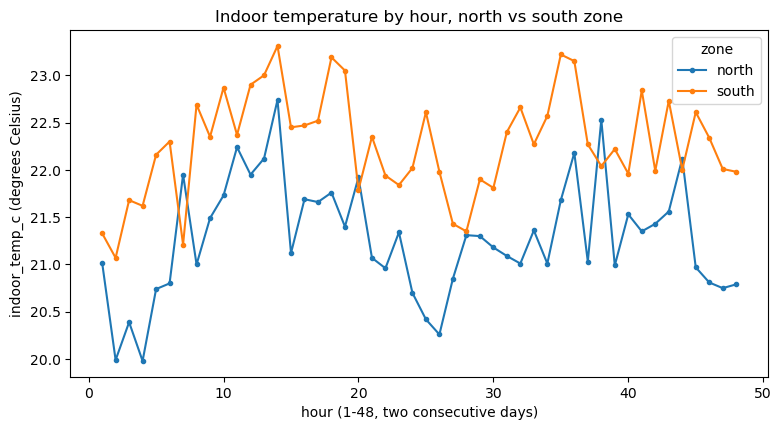

In [11]:
plt.figure(figsize=(9, 4.5))
for zone, group in building.groupby("zone"):
    group = group.sort_values("hour")     # a run plot must follow the time order
    plt.plot(group["hour"], group["indoor_temp_c"], marker="o", markersize=3, label=zone)

plt.xlabel("hour (1-48, two consecutive days)")
plt.ylabel("indoor_temp_c (degrees Celsius)")
plt.title("Indoor temperature by hour, north vs south zone")
plt.legend(title="zone")
plt.show()

**What the plot shows.**

- The **horizontal axis** is `hour`, 1 to 48 — the two days as one continuous sequence. This is a
  **run plot**: unlike a histogram, it keeps the measurements in time order, which is the only way a
  cycle or a drift can become visible.
- The **vertical axis** is `indoor_temp_c` in °C.
- Each **line** is one zone. A point is that zone's single reading for that hour, and the line
  segment simply joins consecutive hours to make the sequence readable — it is not a fitted model
  and says nothing about the minutes between readings.

**The time pattern.**

- **A repeating daily cycle.** Both zones warm through the day to a peak (hour 14 on day 1, and
  again around hours 35–38 on day 2) and cool to a minimum in the early hours (hours 2–4, and
  again near hour 26). Two full cycles across the 48 hours is roughly a **24-hour rhythm**.
- **The south line sits above the north line almost everywhere** — in 44 of the 48 hours, by about
  1 °C on average. The two only cross at hours 7, 20, 38 and 44. The gap is a persistent feature,
  not an occasional one.
- **Both stay inside a narrow band** (north 19.98–22.74 °C, south 21.07–23.31 °C — ranges of about
  2.7 and 2.2 °C). There is no upward or downward **drift** across the two days and no sudden step,
  so the readings look stable in the sense of Session 1's run-plot slide. As that slide warns,
  though, no visible pattern over two days is not proof that the building is stable in general.

## c)

> Create a scatterplot of `outdoor_temp_c` against `energy_kwh`, using colour or separate panels for
> the zones. Describe the direction, form, strength, and unusual points visible in the association.

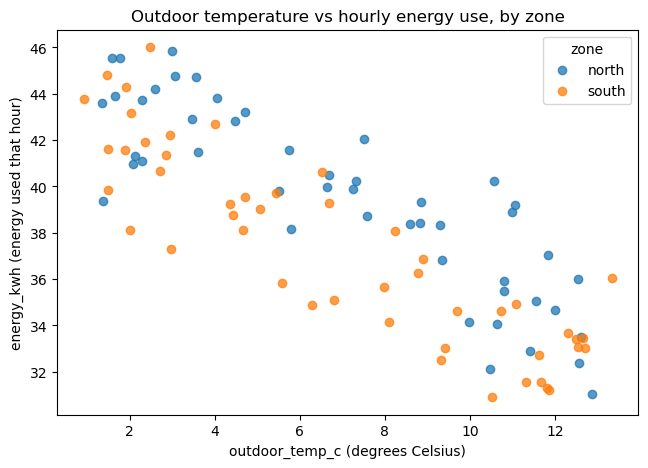

In [12]:
plt.figure(figsize=(7.5, 5))
for zone, group in building.groupby("zone"):
    plt.scatter(group["outdoor_temp_c"], group["energy_kwh"], label=zone, alpha=0.75)

plt.xlabel("outdoor_temp_c (degrees Celsius)")
plt.ylabel("energy_kwh (energy used that hour)")
plt.title("Outdoor temperature vs hourly energy use, by zone")
plt.legend(title="zone")
plt.show()

Each point is **one hourly reading**: its outdoor temperature and the energy that zone used in the
same hour. Colour separates the zones.

- **Direction — negative.** The cloud runs downhill from left to right: the colder the hour
  outdoors, the more energy the zone used. At about 1–3 °C most hours cost 41–46 kWh; above 11 °C
  most cost 31–36 kWh.
- **Form — roughly linear.** The points fall in a straight band. There is no bend, plateau or
  curve that would suggest anything other than a straight-line description.
- **Strength — fairly strong, but not exact.** The band is tight enough that knowing the outdoor
  temperature narrows the likely energy use to a window of about 5 kWh, yet at any given
  temperature the readings still spread by several kWh. So the association is clear but far from
  perfect. (Strength is described from the plot only — no correlation coefficient or fitted line is
  computed here, as those belong to later sessions.)
- **The zones behave alike.** Both colours follow the same downward band and overlap heavily.
  North tends to sit slightly higher for a given outdoor temperature, consistent with its higher
  mean energy in (a).
- **Unusual points.** A few readings sit away from the band:
  - **ID 72** (hour 24, south) — 2.97 °C outdoors but only **37.31 kWh**, while other hours that
    cold used 41–46 kWh.
  - **ID 45** (hour 45, north) — 7.51 °C and **42.05 kWh**, the highest energy in the middle of the
    temperature range.
  - **ID 87** (hour 39, south) — the **warmest** hour in the file at 13.34 °C, yet 36.05 kWh, more
    than several colder hours used.

  All three are perfectly plausible readings, not impossible values, so — exactly as in Part 1 (d) —
  they are described and kept, not removed. Something else that is not in this dataset (occupancy,
  sunshine, a door left open, an equipment schedule) would be needed to explain them.

## d)

> Write a short conclusion about temperature stability, differences between zones, and the visible
> energy–temperature relationship. Do not calculate correlation, fit a regression model, or make
> causal claims at this stage.

**Temperature stability.** Both zones hold their indoor temperature in a narrow band over the full
48 hours — a standard deviation of about 0.6 °C and a total range of little more than 2 °C — with a
gentle daily cycle and no drift or step change. Whatever the building's climate control is doing, it
kept both zones steady across these two days.

**Differences between zones.** The south zone runs about **1 °C warmer** and uses about
**2 kWh less per hour** than the north. Neither difference is a one-off: the south line sits above
the north line in 44 of 48 hours, and the energy gap shows up in the mean and the median alike.
The two zones are, however, equally *stable* — their indoor-temperature standard deviations are
almost identical (0.61 vs 0.55 °C). So they differ in level, not in steadiness.

**The energy–temperature relationship.** Hourly energy use and outdoor temperature show a clear
**negative, roughly linear and fairly strong** association: colder hours go together with higher
energy use, in both zones.

**What this does not establish.** These are descriptions of **96 measurements over two days**.
The scatterplot shows that the two variables *move together*; it does not show that outdoor
temperature **causes** the change in energy use. Sunshine, occupancy, zone size, insulation,
window orientation and equipment schedules are all uncontrolled here, and the north/south labels
may themselves be standing in for several of those at once — which would also be a plausible
reading of why the warmer zone is the cheaper one. No correlation coefficient, regression line or
test has been computed, so "fairly strong" is a statement about the picture and nothing more.
Two days is also a single stretch of weather, which is a thin basis for any claim about the
building in general.

<a id="part3"></a>
# Part 3 — Cybersecurity alert system

_To be completed._

<a id="part4"></a>
# Part 4 — AI-use and conclusion

_To be completed._